In [33]:
import pandas as pd

In [34]:
df=pd.read_csv('public_transport_delays.csv')

In [35]:
df

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,35,4.6,NaN,0,96,0,0,5,Winter,1
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,44,15.4,Festival,0,12,0,1,6,Winter,1
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,32,2.7,NaN,0,24,1,0,6,Summer,1
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,35,8.8,NaN,2000,23,0,0,6,Summer,1


In [36]:
df1=df.drop(['trip_id','date','time','route_id','scheduled_arrival','actual_departure_delay_min','actual_arrival_delay_min','temperature_C','humidity_percent','wind_speed_kmh','precipitation_mm','weekday'],axis=1)

In [37]:
df1

,transport_type,origin_station,destination_station,scheduled_departure,weather_condition,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,season,delayed
0,Tram,Station_31,Station_6,05:02:00,Storm,NaN,500,81,0,1,Winter,0
1,Metro,Station_49,Station_32,05:16:00,Rain,NaN,0,53,0,0,Autumn,1
2,Bus,Station_29,Station_42,05:33:00,Clear,Sports,0,67,1,0,Autumn,0
3,Tram,Station_26,Station_18,05:49:00,Clear,NaN,500,84,0,0,Winter,1
4,Tram,Station_18,Station_15,06:00:00,Snow,NaN,500,46,0,0,Spring,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Bus,Station_46,Station_39,23:46:00,Storm,NaN,0,96,0,0,Winter,1
1996,Train,Station_44,Station_42,00:03:00,Snow,Festival,0,12,0,1,Winter,1
1997,Bus,Station_4,Station_45,00:18:00,Snow,NaN,0,24,1,0,Summer,1
1998,Tram,Station_29,Station_48,00:34:00,Clear,NaN,2000,23,0,0,Summer,1


In [38]:
df1['transport_type']=df1['transport_type'].str.lower()

In [39]:
df1['origin_station']=df1['origin_station'].str.lower()
df1['origin_station']=df1['origin_station'].str.replace('_',' ')

In [40]:
df1['destination_station']=df1['destination_station'].str.lower()
df1['destination_station']=df1['destination_station'].str.replace('_',' ')

In [41]:
df1['scheduled_departure'] = df1['scheduled_departure'].str.slice(0, 5)

In [42]:
def preprocess_input(t):
    h, m = t.split(':')
    return int(h) * 60 + int(m)

df1['scheduled_departure'] = df1['scheduled_departure'].apply(preprocess_input)

In [43]:
df1['weather_condition']=df1['weather_condition'].str.lower()

In [44]:
df1['event_type']=df1['event_type'].fillna('no event')

In [45]:
print(df1['origin_station'].nunique())
print(df1['destination_station'].nunique())

50
50


In [46]:
df1['season']=df1['season'].str.lower()

In [47]:
df1

,transport_type,origin_station,destination_station,scheduled_departure,weather_condition,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,season,delayed
0,tram,station 31,station 6,302,storm,no event,500,81,0,1,winter,0
1,metro,station 49,station 32,316,rain,no event,0,53,0,0,autumn,1
2,bus,station 29,station 42,333,clear,Sports,0,67,1,0,autumn,0
3,tram,station 26,station 18,349,clear,no event,500,84,0,0,winter,1
4,tram,station 18,station 15,360,snow,no event,500,46,0,0,spring,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,bus,station 46,station 39,1426,storm,no event,0,96,0,0,winter,1
1996,train,station 44,station 42,3,snow,Festival,0,12,0,1,winter,1
1997,bus,station 4,station 45,18,snow,no event,0,24,1,0,summer,1
1998,tram,station 29,station 48,34,clear,no event,2000,23,0,0,summer,1


In [48]:
# origin and destination stations with 50 unique values each are likely noise
df1 = df1.drop(['origin_station', 'destination_station'], axis=1)

In [49]:
num_col=[]
str_col=[]

for col in df1:
    if df1[col].dtype=='object':
        str_col.append(col)
    elif df1[col].dtype=='int' or df1[col].dtype=='float':
        num_col.append(col)

In [50]:
num_col.remove('delayed')


In [51]:
num_col

['scheduled_departure',
 'event_attendance_est',
 'traffic_congestion_index',
 'holiday',
 'peak_hour']

In [52]:
str_col

['transport_type', 'weather_condition', 'event_type', 'season']

In [53]:
df1.isnull().sum()

transport_type              0
scheduled_departure         0
weather_condition           0
event_type                  0
event_attendance_est        0
traffic_congestion_index    0
holiday                     0
peak_hour                   0
season                      0
delayed                     0
dtype: int64

In [54]:
df1['delayed'].value_counts()


delayed
1    1499
0     501
Name: count, dtype: int64

In [55]:
x=df1.drop(['delayed'],axis=1)
y=df1['delayed']

In [56]:
x

,transport_type,scheduled_departure,weather_condition,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,season
0,tram,302,storm,no event,500,81,0,1,winter
1,metro,316,rain,no event,0,53,0,0,autumn
2,bus,333,clear,Sports,0,67,1,0,autumn
3,tram,349,clear,no event,500,84,0,0,winter
4,tram,360,snow,no event,500,46,0,0,spring
...,...,...,...,...,...,...,...,...,...
1995,bus,1426,storm,no event,0,96,0,0,winter
1996,train,3,snow,Festival,0,12,0,1,winter
1997,bus,18,snow,no event,0,24,1,0,summer
1998,tram,34,clear,no event,2000,23,0,0,summer


In [57]:
y

0       0
1       1
2       0
3       1
4       1
       ..
1995    1
1996    1
1997    1
1998    1
1999    1
Name: delayed, Length: 2000, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [61]:
preprocessing = ColumnTransformer([
    ('cat', OrdinalEncoder(), str_col)
], remainder='passthrough')  # keeps numeric columns

In [62]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [64]:
from sklearn.preprocessing import StandardScaler

preprocessing = ColumnTransformer([
    ('cat', OrdinalEncoder(), str_col),
    ('num', StandardScaler(), num_col)  # scale numeric columns
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessing),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(x_train, y_train)
print(classification_report(y_test, pipeline.predict(x_test)))

              precision    recall  f1-score   support

           0       0.30      0.11      0.16       106
           1       0.74      0.90      0.81       294

    accuracy                           0.69       400
   macro avg       0.52      0.51      0.49       400
weighted avg       0.62      0.69      0.64       400



In [65]:
pipeline.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [66]:
y_pred=pipeline.predict(x_test)

In [67]:
from sklearn.metrics import f1_score,classification_report,confusion_matrix

In [68]:
print(f1_score(y_test,y_pred))

0.8134556574923547


In [69]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.30      0.11      0.16       106
           1       0.74      0.90      0.81       294

    accuracy                           0.69       400
   macro avg       0.52      0.51      0.49       400
weighted avg       0.62      0.69      0.64       400



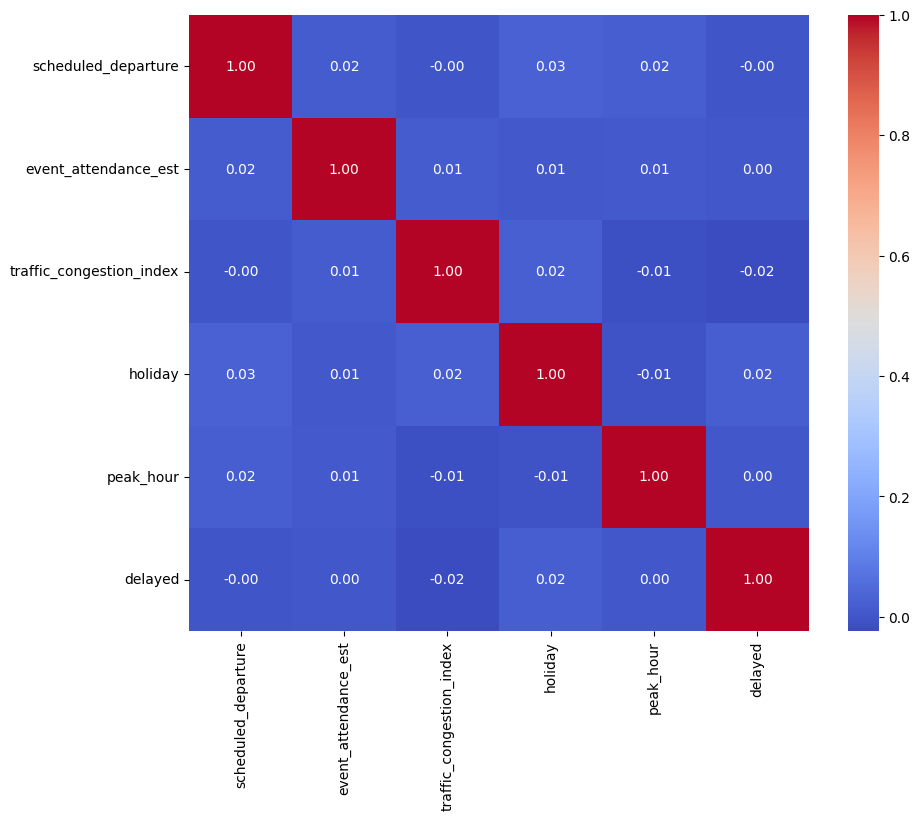

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()